BASE_DIR: C:\Users\bianc\Vision\tpf\speed
VIDEO_PATH: C:\Users\bianc\Vision\tpf\speed\video01\video.mp4
XML_VEHICLES_PATH: C:\Users\bianc\Vision\tpf\speed\video01\vehicles.xml
Patentes con GT: 115


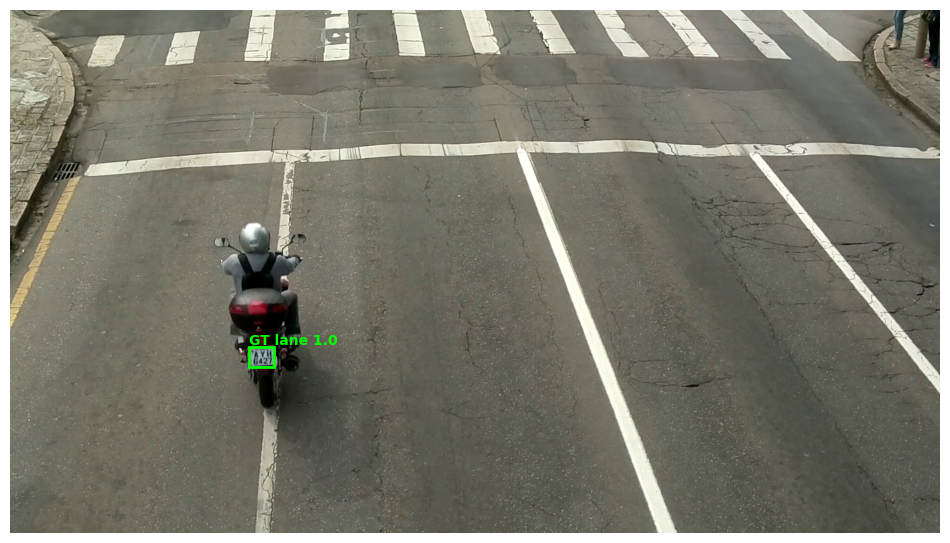

In [2]:
# ================================================================
# Celda 1: imports, paths y Ground Truth de patentes (vehicles.xml)
# ================================================================

from dataclasses import dataclass
from pathlib import Path
from typing import List, Optional, Tuple, Dict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import xml.etree.ElementTree as ET


# ---- Paths base (ajustar si hace falta) ----
BASE_DIR = Path(".").resolve()
VIDEO_PATH = BASE_DIR / "video01" / "video.mp4"
XML_VEHICLES_PATH = BASE_DIR / "video01" / "vehicles.xml"

print("BASE_DIR:", BASE_DIR)
print("VIDEO_PATH:", VIDEO_PATH)
print("XML_VEHICLES_PATH:", XML_VEHICLES_PATH)


# ---- Ground Truth de patentes: vehicles.xml -> DataFrame ----

def build_gt_plates_df(xml_path: Path) -> pd.DataFrame:
    """
    Lee el XML de ground truth y arma un DataFrame con las bounding boxes
    de las patentes (cuando plate="True") y, si existe, info de radar.

    Columnas principales:
      - frame: índice de frame donde se anotó la patente (int).
      - xml_idx: índice de <vehicle> dentro del XML (int).
      - lane: carril (int).
      - x1, y1, x2, y2, w, h: bbox de la patente en píxeles.
      - radar_frame_start, radar_frame_end, radar_speed: info de radar o NaN.
    """
    tree = ET.parse(str(xml_path))
    root = tree.getroot()

    entries = []
    for idx, veh in enumerate(root.findall(".//vehicle")):
        if veh.get("plate", "False").lower() != "true":
            continue

        frame = int(veh.get("iframe"))
        lane = int(veh.get("lane"))

        region = veh.find("region")
        if region is None:
            continue

        x = int(region.get("x"))
        y = int(region.get("y"))
        w = int(region.get("w"))
        h = int(region.get("h"))

        x1, y1 = x, y
        x2, y2 = x + w, y + h

        radar = veh.find("radar")
        if radar is not None:
            radar_start = int(radar.get("frame_start"))
            radar_end = int(radar.get("frame_end"))
            radar_speed = float(radar.get("speed"))
        else:
            radar_start = np.nan
            radar_end = np.nan
            radar_speed = np.nan

        entries.append(
            {
                "frame": frame,
                "xml_idx": idx,
                "lane": lane,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "w": w,
                "h": h,
                "radar_frame_start": radar_start,
                "radar_frame_end": radar_end,
                "radar_speed": radar_speed,
            }
        )

    df = pd.DataFrame(entries)
    return df


def iou_xyxy(boxA: Tuple[int, int, int, int],
             boxB: Tuple[int, int, int, int]) -> float:
    """
    Calcula el IoU entre dos cajas en formato (x1, y1, x2, y2).
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter = inter_w * inter_h
    if inter == 0:
        return 0.0

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    denom = float(areaA + areaB - inter)
    if denom <= 0:
        return 0.0

    return inter / denom


def load_frame(video_path: Path, frame_idx: int) -> Optional[np.ndarray]:
    """
    Carga un frame del video dado un índice.
    Devuelve imagen BGR o None si falla.
    """
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_idx < 0 or frame_idx >= total_frames:
        print(f"[load_frame] Frame {frame_idx} fuera de rango (0..{total_frames-1})")
        cap.release()
        return None

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"[load_frame] No se pudo leer el frame {frame_idx}")
        return None

    return frame


def show_gt_plate(frame_idx: int,
                  df_gt: pd.DataFrame,
                  video_path: Path,
                  figsize=(12, 7)) -> None:
    """
    Muestra el frame y dibuja las cajas GT de patente (en verde).
    """
    frame = load_frame(video_path, frame_idx)
    if frame is None:
        return

    subset = df_gt[df_gt["frame"] == frame_idx]
    if subset.empty:
        print(f"No hay GT de patente para el frame {frame_idx}")
        return

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.axis("off")

    for _, row in subset.iterrows():
        rect = patches.Rectangle(
            (row["x1"], row["y1"]),
            row["w"],
            row["h"],
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            row["x1"],
            row["y1"] - 5,
            f"GT lane {row['lane']}",
            color="lime",
            fontsize=10,
            fontweight="bold",
        )

    plt.show()


# ---- Construimos df_gt una vez ----
df_gt = build_gt_plates_df(XML_VEHICLES_PATH)
print(f"Patentes con GT: {len(df_gt)}")

if not df_gt.empty:
    show_gt_plate(int(df_gt.iloc[0]["frame"]), df_gt, VIDEO_PATH)


In [3]:
# ==========================================================
# Celda 2: pipeline Luvizon-like (edges, grouping, “T-HOG”)
# ==========================================================

@dataclass
class EdgeRegion:
    x: int
    y: int
    w: int
    h: int

    @property
    def x2(self) -> int:
        return self.x + self.w

    @property
    def y2(self) -> int:
        return self.y + self.h

    @property
    def cx(self) -> float:
        return self.x + self.w / 2.0

    @property
    def cy(self) -> float:
        return self.y + self.h / 2.0


class DSU:
    """
    Union-Find simple para agrupar regiones compatibles.
    """

    def __init__(self, n: int):
        self.parent = list(range(n))

    def find(self, x: int) -> int:
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a: int, b: int) -> None:
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[rb] = ra


# ---------- Etapa 1: extracción y filtrado de bordes ----------

def vertical_edges_sobel(gray: np.ndarray,
                         sobel_ksize: int = 3,
                         tau: float = 2.0) -> np.ndarray:
    """
    Implementa E(x,y) de la ecuación (3) del paper:
      - Gx: Sobel horizontal 3x3.
      - µ: valor medio de |Gx|.
      - E(x,y)=1 si |Gx| > µ * tau.

    Devuelve una imagen binaria 0/255 (uint8).
    """
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=sobel_ksize)
    mag = np.abs(gx)
    mu = float(mag.mean())
    if mu <= 0:
        return np.zeros_like(gray, dtype=np.uint8)

    edges = (mag > (mu * tau)).astype(np.uint8) * 255
    return edges


def filter_edge_components(edge_img: np.ndarray,
                           min_w: int = 4,
                           max_w: int = 120,
                           min_h: int = 1,
                           max_h: int = 9999) -> np.ndarray:
    """
    Filtra componentes conectados en la imagen de bordes:
    descarta cajas con ancho/alto fuera de [min,max].

    Devuelve nueva imagen binaria con solo componentes válidos.
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        edge_img, connectivity=8
    )

    filtered = np.zeros_like(edge_img, dtype=np.uint8)

    for label in range(1, num_labels):
        x, y, w, h, area = stats[label]
        if (min_w <= w <= max_w) and (min_h <= h <= max_h):
            filtered[labels == label] = 255

    return filtered


def dilate_edges(edge_img: np.ndarray,
                 kernel_size: Tuple[int, int] = (1, 7)) -> np.ndarray:
    """
    Dilata los bordes usando un elemento estructurante (1 x 7),
    como en el paper.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    dilated = cv2.dilate(edge_img, kernel, iterations=1)
    return dilated


# ---------- Etapa 2: regiones y agrupamiento ----------

def build_regions_from_edges(edge_img: np.ndarray,
                             min_w: int = 4,
                             max_w: int = 9999,
                             min_h: int = 1,
                             max_h: int = 9999) -> List[EdgeRegion]:
    """
    A partir de una imagen binaria, obtiene bounding boxes de cada
    componente conectado y filtra por tamaño.
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        edge_img, connectivity=8
    )
    regions: List[EdgeRegion] = []

    for label in range(1, num_labels):
        x, y, w, h, area = stats[label]
        if (min_w <= w <= max_w) and (min_h <= h <= max_h):
            regions.append(EdgeRegion(int(x), int(y), int(w), int(h)))

    return regions


def compatible_regions(a: EdgeRegion, b: EdgeRegion,
                       t1: float = 0.7,
                       t2: float = 1.1,
                       t3: float = 0.4) -> bool:
    """
    Criterio geométrico de compatibilidad de Retornaz & Marcotegui (ec. 4).
    """
    h1, h2 = a.h, b.h
    h = min(h1, h2)
    if h <= 0:
        return False

    dx = abs(a.cx - b.cx) - (a.w + b.w) / 2.0
    dy = abs(a.cy - b.cy)

    return (abs(h1 - h2) < t1 * h) and (dx < t2 * h) and (dy < t3 * h)


def group_regions(regions: List[EdgeRegion]) -> List[List[EdgeRegion]]:
    """
    Agrupa regiones compatibles mediante union-find.
    Devuelve lista de grupos (cada grupo es una lista de EdgeRegion).
    """
    n = len(regions)
    if n == 0:
        return []

    dsu = DSU(n)
    for i in range(n):
        for j in range(i + 1, n):
            if compatible_regions(regions[i], regions[j]):
                dsu.union(i, j)

    groups_dict: Dict[int, List[EdgeRegion]] = {}
    for idx in range(n):
        root = dsu.find(idx)
        groups_dict.setdefault(root, []).append(regions[idx])

    return list(groups_dict.values())


def groups_to_candidate_bboxes(groups: List[List[EdgeRegion]],
                               min_plate_w: int = 32,
                               min_plate_h: int = 10) -> List[Tuple[int, int, int, int]]:
    """
    Convierte grupos de EdgeRegion en bboxes de candidatos
    y filtra por tamaño mínimo de patente.
    """
    candidates: List[Tuple[int, int, int, int]] = []

    for group in groups:
        x1 = min(r.x for r in group)
        y1 = min(r.y for r in group)
        x2 = max(r.x2 for r in group)
        y2 = max(r.y2 for r in group)
        w = x2 - x1
        h = y2 - y1
        if w >= min_plate_w and h >= min_plate_h:
            candidates.append((int(x1), int(y1), int(x2), int(y2)))

    return candidates


# ---------- Etapa 3: clasificación "texto / no texto" ----------

def text_window_score(patch_gray: np.ndarray) -> float:
    """
    Score simple de "parecido a texto" en una ventana:
      - calcula gradientes Gx, Gy
      - usa media y desvío de la magnitud como proxy de textura/contorno.

    Cuanto mayor el score, más probable que haya caracteres.
    """
    gx = cv2.Sobel(patch_gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(patch_gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx * gx + gy * gy)

    mean_mag = float(mag.mean())
    std_mag = float(mag.std())
    score = mean_mag * (1.0 + std_mag)

    return score


def classify_region_textlike(gray: np.ndarray,
                             edges_dilated: np.ndarray,
                             bbox: Tuple[int, int, int, int],
                             win_w: int = 48,
                             win_h: int = 24,
                             step: int = 4) -> Tuple[float, int]:
    """
    Aproximación a la etapa T-HOG/SVM del paper (Fig. 12):

      - Recibe la imagen en gris, la imagen de bordes dilatada y
        una bbox candidata (x1,y1,x2,y2).
      - Estima la "línea central" de bordes (centro entre píxel
        más alto y más bajo en cada columna con bordes).
      - Centra ventanas de tamaño fijo a lo largo de esa línea,
        espaciadas cada `step` píxeles.
      - Calcula un score de texto para cada ventana.
      - Devuelve:
          * region_score: score global de la región (densidad de texto).
          * n_pos: número de ventanas consideradas como "texto".

    Esta función NO usa el T-HOG original ni un SVM entrenado.
    Es una heurística inspirada en la descripción del paper.
    """
    x1, y1, x2, y2 = bbox
    H, W = gray.shape

    x1_c = max(x1, 0)
    y1_c = max(y1, 0)
    x2_c = min(x2, W)
    y2_c = min(y2, H)

    if x2_c <= x1_c or y2_c <= y1_c:
        return 0.0, 0

    crop_edges = edges_dilated[y1_c:y2_c, x1_c:x2_c]
    crop_gray = gray[y1_c:y2_c, x1_c:x2_c]
    h, w = crop_gray.shape

    # Línea central: para cada columna, centro entre pixel más alto y más bajo con borde
    center_points: List[Tuple[int, int]] = []
    for j in range(w):
        col = crop_edges[:, j]
        ys = np.where(col > 0)[0]
        if ys.size == 0:
            continue
        cy = int((int(ys[0]) + int(ys[-1])) / 2)
        center_points.append((j, cy))

    if not center_points:
        return 0.0, 0

    # Ventanas a lo largo de la línea central
    half_w = win_w // 2
    half_h = win_h // 2

    scores: List[float] = []
    for idx, (cx_local, cy_local) in enumerate(center_points[::step]):
        cx = x1_c + cx_local
        cy = y1_c + cy_local

        x0_win = max(cx - half_w, 0)
        x1_win = min(cx + half_w, W - 1)
        y0_win = max(cy - half_h, 0)
        y1_win = min(cy + half_h, H - 1)

        patch = gray[y0_win:y1_win, x0_win:x1_win]
        if patch.size == 0 or patch.shape[0] < 8 or patch.shape[1] < 8:
            continue

        scores.append(text_window_score(patch))

    if not scores:
        return 0.0, 0

    scores_arr = np.array(scores, dtype=np.float32)

    # Umbral adaptativo: ventanas con score > media + 0.3*std
    mu = float(scores_arr.mean())
    sigma = float(scores_arr.std())
    thr = mu + 0.3 * sigma

    positive = scores_arr[scores_arr > thr]
    if positive.size == 0:
        return 0.0, 0

    density = positive.size / scores_arr.size
    region_score = float(density * positive.mean())

    return region_score, int(positive.size)


# ---------- Etapa 4: detección en una ROI ----------

def detect_plate_region_luvizon(
    roi_bgr: np.ndarray,
    min_edge_w: int = 4,
    max_edge_w: int = 120,
    min_plate_w: int = 32,
    min_plate_h: int = 10,
    tau: float = 2.0,
) -> Optional[Tuple[int, int, int, int]]:
    """
    Detector de patente estilo Luvizon para UNA ROI (imagen BGR).

    Devuelve (x1,y1,x2,y2) en coordenadas de la ROI o None si falla.
    """
    if roi_bgr is None or roi_bgr.size == 0:
        return None

    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # 1) Bordes verticales
    edges = vertical_edges_sobel(gray, tau=tau)

    # 2) Filtrado de componentes chicos/grandes
    edges_filt = filter_edge_components(
        edges,
        min_w=min_edge_w,
        max_w=max_edge_w,
        min_h=1,
        max_h=9999,
    )

    # 3) Dilatación 1x7
    edges_dil = dilate_edges(edges_filt, kernel_size=(1, 7))

    # 4) Regiones y agrupamiento
    regions = build_regions_from_edges(
        edges_dil,
        min_w=min_edge_w,
        max_w=max_edge_w,
        min_h=1,
        max_h=9999,
    )
    if not regions:
        return None

    groups = group_regions(regions)
    candidates = groups_to_candidate_bboxes(
        groups,
        min_plate_w=min_plate_w,
        min_plate_h=min_plate_h,
    )
    if not candidates:
        return None

    # 5) Clasificación “texto / no texto”
    H, W = gray.shape
    best_bbox = None
    best_score = 0.0

    for (x1, y1, x2, y2) in candidates:
        # Clampeamos por las dudas
        x1_c = max(x1, 0)
        y1_c = max(y1, 0)
        x2_c = min(x2, W)
        y2_c = min(y2, H)
        if x2_c <= x1_c or y2_c <= y1_c:
            continue

        score, n_pos = classify_region_textlike(
            gray, edges_dil, (x1_c, y1_c, x2_c, y2_c)
        )
        if n_pos == 0:
            continue

        # Penalizamos regiones muy altas en la imagen: queremos algo cerca del bottom
        bottom_dist = H - y2_c
        score_adj = float(score * (1.0 + 0.001 * (H - bottom_dist)))

        if score_adj > best_score:
            best_score = score_adj
            best_bbox = (x1_c, y1_c, x2_c, y2_c)

    return best_bbox


Ejemplo visual en frame: 373


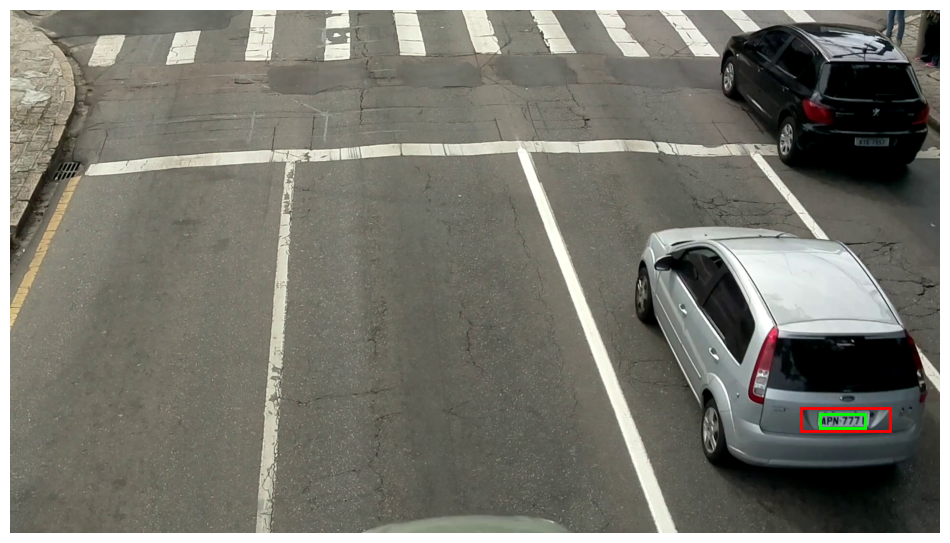

Total frames video: 6918
Frames usados en evaluación: 115
Procesados 20/115 frames...
Procesados 40/115 frames...
Procesados 60/115 frames...
Procesados 80/115 frames...
Procesados 100/115 frames...
df_eval shape: (115, 14)
Total patentes GT: 115
Con predicción: 115 (100.0%)
Hit IoU>=0.5: 19 (16.5%)
IoU medio: 0.143


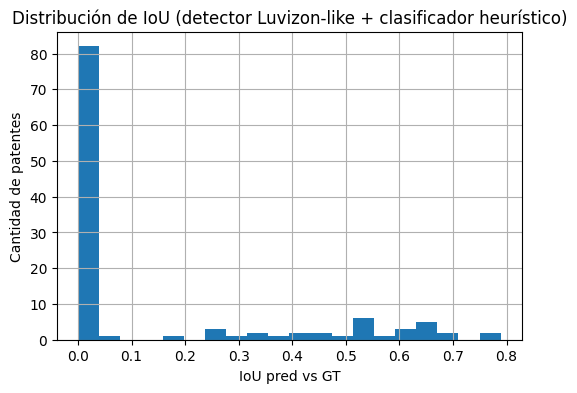

Métricas por carril:
      total  hit_05  mean_iou  hit_05_pct
lane                                     
1        30       1  0.047080    3.333333
2        43       9  0.140368   20.930233
3        42       9  0.213607   21.428571


In [4]:
# ============================================================
# Celda 3: wrapper por frame, evaluación y ejemplos visuales
# ============================================================

def detect_plates_in_frame(
    frame_bgr: np.ndarray,
    rois: Optional[List[Tuple[int, int, int, int]]] = None,
    **luvizon_kwargs,
) -> List[Tuple[int, int, int, int]]:
    """
    Corre el detector Luvizon-like en un frame completo o en una lista de ROIs.

    Parámetros:
      - frame_bgr: imagen BGR.
      - rois: lista de bboxes (x1,y1,x2,y2) donde buscar la patente.
              Si es None, usa el frame entero como ROI.
      - luvizon_kwargs: parámetros extra para detect_plate_region_luvizon().

    Devuelve lista de bboxes de patentes en coords del frame.
    """
    H, W, _ = frame_bgr.shape
    results: List[Tuple[int, int, int, int]] = []

    if rois is None:
        bbox = detect_plate_region_luvizon(frame_bgr, **luvizon_kwargs)
        if bbox is not None:
            results.append(bbox)
        return results

    # Con ROIs (p.ej. bboxes de vehículos)
    for (x1, y1, x2, y2) in rois:
        x1_c = max(int(x1), 0)
        y1_c = max(int(y1), 0)
        x2_c = min(int(x2), W)
        y2_c = min(int(y2), H)
        if x2_c <= x1_c or y2_c <= y1_c:
            continue

        roi = frame_bgr[y1_c:y2_c, x1_c:x2_c]
        bbox_roi = detect_plate_region_luvizon(roi, **luvizon_kwargs)
        if bbox_roi is None:
            continue

        # Pasamos a coords del frame
        bx1, by1, bx2, by2 = bbox_roi
        results.append((bx1 + x1_c, by1 + y1_c, bx2 + x2_c - (x2_c - bx2), by2 + y1_c))

    return results


def show_detection_example(frame_idx: int,
                           df_gt: pd.DataFrame,
                           video_path: Path,
                           rois_by_frame: Optional[Dict[int, List[Tuple[int, int, int, int]]]] = None,
                           figsize=(12, 7)) -> None:
    """
    Muestra un frame con:
      - cajas GT de patente (verde)
      - predicciones Luvizon-like (rojo)
    """
    frame = load_frame(video_path, frame_idx)
    if frame is None:
        return

    rois = None
    if rois_by_frame is not None:
        rois = rois_by_frame.get(frame_idx, None)

    preds = detect_plates_in_frame(frame, rois=rois)

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.axis("off")

    # GT
    subset = df_gt[df_gt["frame"] == frame_idx]
    for _, row in subset.iterrows():
        rect = patches.Rectangle(
            (row["x1"], row["y1"]),
            row["w"],
            row["h"],
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)

    # Predicciones
    for (x1, y1, x2, y2) in preds:
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)

    plt.show()


def run_luvizon_detection_on_gt(
    df_gt: pd.DataFrame,
    video_path: Path,
    rois_by_frame: Optional[Dict[int, List[Tuple[int, int, int, int]]]] = None,
    max_frames: Optional[int] = None,
    **luvizon_kwargs,
) -> pd.DataFrame:
    """
    Corre el detector Luvizon-like sobre los frames que tienen GT de patente
    y arma un DataFrame con IoU por patente.

    Si rois_by_frame no es None, usa esas ROIs (p.ej. bboxes de vehículos)
    por frame; si es None, usa el frame completo como ROI.

    Devuelve df_eval con columnas:
      frame, xml_idx, lane,
      x1_gt, y1_gt, x2_gt, y2_gt,
      x1_pred, y1_pred, x2_pred, y2_pred,
      iou, has_pred, hit_05
    """
    unique_frames = sorted(df_gt["frame"].unique())
    if max_frames is not None:
        unique_frames = unique_frames[:max_frames]

    rows = []

    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total frames video: {total_frames}")
    print(f"Frames usados en evaluación: {len(unique_frames)}")

    for i, frame_idx in enumerate(unique_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        ret, frame = cap.read()
        if not ret:
            print(f"[run_luvizon_detection_on_gt] No se pudo leer frame {frame_idx}")
            continue

        rois = None
        if rois_by_frame is not None:
            rois = rois_by_frame.get(frame_idx, None)

        preds = detect_plates_in_frame(frame, rois=rois, **luvizon_kwargs)
        if preds:
            # Por simplicidad, tomamos solo el primer candidato
            x1_p, y1_p, x2_p, y2_p = preds[0]
            has_pred = True
        else:
            x1_p = y1_p = x2_p = y2_p = np.nan
            has_pred = False

        gt_rows = df_gt[df_gt["frame"] == frame_idx]
        for _, gt in gt_rows.iterrows():
            box_gt = (int(gt["x1"]), int(gt["y1"]), int(gt["x2"]), int(gt["y2"]))
            if has_pred:
                box_pred = (int(x1_p), int(y1_p), int(x2_p), int(y2_p))
                iou = iou_xyxy(box_gt, box_pred)
            else:
                iou = 0.0

            rows.append(
                {
                    "frame": int(frame_idx),
                    "xml_idx": int(gt["xml_idx"]),
                    "lane": int(gt["lane"]),
                    "x1_gt": box_gt[0],
                    "y1_gt": box_gt[1],
                    "x2_gt": box_gt[2],
                    "y2_gt": box_gt[3],
                    "x1_pred": x1_p,
                    "y1_pred": y1_p,
                    "x2_pred": x2_p,
                    "y2_pred": y2_p,
                    "iou": float(iou),
                    "has_pred": has_pred,
                    "hit_05": bool(iou >= 0.5),
                }
            )

        if (i + 1) % 20 == 0:
            print(f"Procesados {i+1}/{len(unique_frames)} frames...")

    cap.release()
    df_eval = pd.DataFrame(rows)
    return df_eval


# ----------------------------------------------------------
# Ejecución de ejemplo (usar frame completo como única ROI)
# ----------------------------------------------------------

# 1) Un frame random de ej. visual
if not df_gt.empty:
    example_frame = int(df_gt.sample(1, random_state=0)["frame"].iloc[0])
    print("Ejemplo visual en frame:", example_frame)
    show_detection_example(example_frame, df_gt, VIDEO_PATH)

# 2) Evaluación rápida (podés limitar max_frames para debug)
df_eval = run_luvizon_detection_on_gt(
    df_gt,
    VIDEO_PATH,
    rois_by_frame=None,   # más adelante podés pasar ROIs de vehículos
    max_frames=200,       # ponelo en None para todo el dataset
    tau=2.0,
)

print("df_eval shape:", df_eval.shape)

if not df_eval.empty:
    total = len(df_eval)
    with_pred = int(df_eval["has_pred"].sum())
    hits = int(df_eval["hit_05"].sum())
    mean_iou = float(df_eval["iou"].mean())

    print(f"Total patentes GT: {total}")
    print(f"Con predicción: {with_pred} ({with_pred/total*100:.1f}%)")
    print(f"Hit IoU>=0.5: {hits} ({hits/total*100:.1f}%)")
    print(f"IoU medio: {mean_iou:.3f}")

    plt.figure(figsize=(6, 4))
    df_eval["iou"].hist(bins=20)
    plt.xlabel("IoU pred vs GT")
    plt.ylabel("Cantidad de patentes")
    plt.title("Distribución de IoU (detector Luvizon-like + clasificador heurístico)")
    plt.show()

    lane_stats = (
        df_eval.groupby("lane")
        .agg(
            total=("hit_05", "size"),
            hit_05=("hit_05", "sum"),
            mean_iou=("iou", "mean"),
        )
    )
    lane_stats["hit_05_pct"] = 100.0 * lane_stats["hit_05"] / lane_stats["total"]
    print("Métricas por carril:")
    print(lane_stats)
else:
    print("df_eval vacío, no hay métricas.")
